# 1. Importation de packages

In [ ]:
import os
import pandas as pd
import numpy as np
from utils import charger_donnees_api, imputer_na_par_valeur, tracer_series_temporelles, sauvegarder_donnees_clean, classifier_risque, construire_features, creer_cible_binaire

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

import joblib


from xgboost import XGBClassifier


# 2. Importation des données

On définit le dossier de données qui n'est créé que s'il n'existe pas encore dans le repertoire de travail.

In [2]:
DOSSIER_DONNEES = "data/raw"
os.makedirs(DOSSIER_DONNEES, exist_ok=True)

Nous importons ici les données sur les pollens via  l'api open-meteo (**air-quality** pour les données sur les pollens et **archives** pour les données météo); nous avons considéré les données sur un an du 1er janvier 2023 au 01 janvier 2024 pour Rennes.

Données Pollen

In [3]:
url_pollen = "https://air-quality-api.open-meteo.com/v1/air-quality"

params_pollen = {
    "latitude": 48.11,
    "longitude": -1.67,
    "hourly": ["birch_pollen", "grass_pollen"],
    "start_date": "2021-01-01",
    "end_date": "2026-04-19"
}

fichier_pollen = os.path.join(DOSSIER_DONNEES, "pollen.csv")


df_pol = charger_donnees_api(
    url=url_pollen,
    params=params_pollen,
    fichier_cache=fichier_pollen,
    force_reload= False
)


Données météo

In [4]:
url_meteo = "https://archive-api.open-meteo.com/v1/archive"

params_meteo = {
    "latitude": 48.11,
    "longitude": -1.67,
    "hourly": ["temperature_2m", "precipitation", "wind_speed_10m"],
    "start_date": "2021-01-01",
    "end_date": "2026-04-19",
    "timezone": "Europe/Paris"
}

fichier_meteo = os.path.join(DOSSIER_DONNEES, "meteo.csv")


df_met = charger_donnees_api(
    url=url_meteo,
    params=params_meteo,
    fichier_cache=fichier_meteo,
    force_reload= False
)

# 3.Fusion et analyse exploratoire

Pour éviter de travailler sur les bases originales, on va travailler sur les copies de ces bases.

In [5]:
df_meteo = df_met.copy()
df_pollen = df_pol.copy()

## 3.1. Fusion des bases
Pour répondre à la thématique, nous devons fusionner les deux bases; Mais avant  toute fusion, il faut vérifier la structure des deux bases et surtout explorer la clé de fusion qui ici est la date.
Ci-dessous, un aperçu des deux bases:

In [6]:
pd.concat(
    [df_pollen.head(), df_meteo.head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

Pollen                                         Meteo  \
                 date birch_pollen grass_pollen                date   
0 2021-01-01 00:00:00          0.0          0.0 2021-01-01 00:00:00   
1 2021-01-01 01:00:00          0.0          0.0 2021-01-01 01:00:00   
2 2021-01-01 02:00:00          0.0          0.0 2021-01-01 02:00:00   
3 2021-01-01 03:00:00          0.0          0.0 2021-01-01 03:00:00   
4 2021-01-01 04:00:00          0.0          0.0 2021-01-01 04:00:00   

                                               
  temperature_2m precipitation wind_speed_10m  
0           -0.4           0.0            2.9  
1           -1.4           0.0            2.1  
2           -1.9           0.0            3.6  
3           -2.5           0.0            2.3  
4           -2.5           0.0            4.3

Pour faciliter la lisibilité et la manipulation des variables, il est nécessaire de les renommer.

In [7]:
df_pollen = df_pollen.rename(columns={
    "birch_pollen": "pollen_bouleau",
    "grass_pollen": "pollen_graminees"
})

df_meteo = df_meteo.rename(columns={
    "temperature_2m": "temperature",
    "precipitation": "precipitations",
    "wind_speed_10m": "vitesse_vent"
})

pd.concat(
    [df_pollen.head(), df_meteo.head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

Pollen                                               Meteo  \
                 date pollen_bouleau pollen_graminees                date   
0 2021-01-01 00:00:00            0.0              0.0 2021-01-01 00:00:00   
1 2021-01-01 01:00:00            0.0              0.0 2021-01-01 01:00:00   
2 2021-01-01 02:00:00            0.0              0.0 2021-01-01 02:00:00   
3 2021-01-01 03:00:00            0.0              0.0 2021-01-01 03:00:00   
4 2021-01-01 04:00:00            0.0              0.0 2021-01-01 04:00:00   

                                           
  temperature precipitations vitesse_vent  
0        -0.4            0.0          2.9  
1        -1.4            0.0          2.1  
2        -1.9            0.0          3.6  
3        -2.5            0.0          2.3  
4        -2.5            0.0          4.3

Afin de garantir l'intégrité de nos deux bases qui sont temporelles, nous vérifions la régularité du pas de temps via le calcul des différences successives (.diff()). Cette étape confirme la continuité des observations horaires et l'absence de dates manquantes.

In [8]:
pd.concat(
    [df_pollen["date"].diff().value_counts().head(), df_meteo["date"].diff().value_counts().head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

,Pollen,Meteo
date,,
0 days 01:00:00,43823,43823


Vérifions que les périodes se chevauchent pour les deux bases. ça devrait être le cas au regard des paramètres d'importation mais la vérification en vaut la peine.

In [9]:
pd.DataFrame({
    "Pollen": [df_pollen["date"].min(), df_pollen["date"].max()],
    "Meteo": [df_meteo["date"].min(), df_meteo["date"].max()]
}, index=["Min date", "Max date"])

,Pollen,Meteo
Min date,2021-01-01 00:00:00,2021-01-01 00:00:00
Max date,2025-12-31 23:00:00,2025-12-31 23:00:00


On remarque que les données des deux bases sont sans fuseau attachés, ce qui facilite la fusion locale en prenant la date comme clé de fusion.

In [10]:
print(df_meteo["date"].dt.tz)
print(df_pollen["date"].dt.tz)

None
None


On se rend également compte qu'avant la fusion, il n y a pas de valeur manquante dans la base météo.

In [11]:
pd.concat(
    [df_pollen.isnull().sum(), df_meteo.isnull().sum()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

,Pollen,Meteo
date,0.0,0.0
pollen_bouleau,12791.0,NaN
pollen_graminees,10559.0,NaN
temperature,NaN,0.0
precipitations,NaN,0.0
vitesse_vent,NaN,0.0


**Fusion des deux bases**
Fusion des deux bases: avec toutes les vérifications qui viennent d'être faites sur la variable date qui est la clé primaire ici, on  peut fusionner simplement avec un inner_join (correspondances exactes)

In [12]:
df_pollen_meteo = pd.merge(df_pollen, df_meteo, on="date", how="inner")

df_pollen_meteo.to_csv("data/raw/df_pollen_meteo_merge.csv")

print(df_pollen_meteo.shape)
df_pollen_meteo.head()

(43824, 6)


,date,pollen_bouleau,pollen_graminees,temperature,precipitations,vitesse_vent
0,2021-01-01 00:00:00,0.0,0.0,-0.4,0.0,2.9
1,2021-01-01 01:00:00,0.0,0.0,-1.4,0.0,2.1
2,2021-01-01 02:00:00,0.0,0.0,-1.9,0.0,3.6
3,2021-01-01 03:00:00,0.0,0.0,-2.5,0.0,2.3
4,2021-01-01 04:00:00,0.0,0.0,-2.5,0.0,4.3


## 3.2. Exploration et traitement de la base d'étude

In [13]:
print("\n--- Informations détaillées (Check-up complet) ---")
df_pollen_meteo.info()


--- Informations détaillées (Check-up complet) ---
<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              43824 non-null  datetime64[us]
 1   pollen_bouleau    31033 non-null  float64       
 2   pollen_graminees  33265 non-null  float64       
 3   temperature       43824 non-null  float64       
 4   precipitations    43824 non-null  float64       
 5   vitesse_vent      43824 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 2.0 MB


In [14]:
df_pollen_meteo.isnull().sum()

date                    0
pollen_bouleau      12791
pollen_graminees    10559
temperature             0
precipitations          0
vitesse_vent            0
dtype: int64


**Interprétation des valeurs manquantes**

L’analyse des périodes manquantes montre qu’elles correspondent en réalité à des **phases biologiques naturelles** et non à des erreurs de collecte de données.

Pour le pollen de bouleau, les données sont absentes de janvier à fin février, ce qui correspond à une période de dormance. Elles sont présentes de mars à début août, période de pollinisation, puis redeviennent absentes à partir d’août jusqu'au 20 novembre, marquant la fin de la saison.

Pour les graminées, les données sont également absentes en hiver (janvier-février), présentes de mars à début septembre, ce qui reflète une saison de pollinisation plus longue, puis absentes à nouveau à partir de septembre jusqu'au 20 novembre.

Ces résultats sont cohérents avec les connaissances biologiques et confirment que les valeurs manquantes ne sont pas problématiques, mais traduisent simplement l’absence de pollen hors saison. Cela nous emmene donc à imputer ces valeurs manquantes par des 0.

In [15]:
from IPython.display import display, HTML
from utils import identifier_plages_manquantes

# Bouleau
display(HTML("<b>Périodes manquantes pour le Pollen de bouleau</b>"))
plages_bouleau = identifier_plages_manquantes(df_pollen_meteo, 'pollen_bouleau')
display(plages_bouleau)

# Graminées
display(HTML("<b>Périodes manquantes pour les graminées</b>"))
plages_graminees = identifier_plages_manquantes(df_pollen_meteo, 'pollen_graminees')
display(plages_graminees)

--- Analyse : pollen_bouleau ---
Total NaN dans la colonne : 12791
Total identifié par blocs : 12791
Vérification : OK (Tous les NaN sont comptabilisés).


,date_debut,date_fin,heures_manquantes,total_cumule_manquant
0,2021-08-01 00:00:00,2022-02-28 23:00:00,5088,5088
1,2022-08-01 00:00:00,2023-02-28 23:00:00,5088,10176
2,2023-08-04 01:00:00,2023-11-20 23:00:00,2615,12791


--- Analyse : pollen_graminees ---
Total NaN dans la colonne : 10559
Total identifié par blocs : 10559
Vérification : OK (Tous les NaN sont comptabilisés).


,date_debut,date_fin,heures_manquantes,total_cumule_manquant
0,2021-09-01 00:00:00,2022-02-28 23:00:00,4344,4344
1,2022-09-01 00:00:00,2023-02-28 23:00:00,4344,8688
2,2023-09-04 01:00:00,2023-11-20 23:00:00,1871,10559


Bien qu'après le 20 novembre 2023, les données ne soient pas manquantes pour ces deux variables de pollen, les valeurs qu'elles prennent sont nulles comme on peut le voir sur les graphiques plus bas;
Ce même comportement est observé pour les mêmes périodes des années 2024 et 2025;  ce qui est normal vu que la période novembre-decembre n'est pas leur saison. 

In [16]:
# Définition de la borne temporelle (juste après le dernier NaN)
date_reprise = "2023-11-20 23:00:00"

# Création du sous-ensemble de données pour la fin d'année
df_fin_annee = df_pollen_meteo[df_pollen_meteo['date'] > date_reprise].copy()

# Calcul des statistiques pour se rassurer
stats_fin_annee = df_fin_annee[['pollen_bouleau', 'pollen_graminees']].agg(['max', 'min','mean', 'sum', 'count'])

print(f"--- Analyse de la période : du {df_fin_annee['date'].min()} au {df_fin_annee['date'].max()} ---")
print(f"Nombre total d'heures analysées : {len(df_fin_annee)}")
print("\nStatistiques des pollens sur cette période :")
display(stats_fin_annee)

--- Analyse de la période : du 2023-11-21 00:00:00 au 2025-12-31 23:00:00 ---
Nombre total d'heures analysées : 18528

Statistiques des pollens sur cette période :


,pollen_bouleau,pollen_graminees
max,344.900000,136.500000
min,0.000000,0.000000
mean,2.096557,5.147372
sum,38845.000000,95370.500000
count,18528.000000,18528.000000


**Imputation des valeurs manquantes par 0**

In [17]:
colonnes_pollen = ['pollen_bouleau', 'pollen_graminees']

df_pollen_meteo_clean = imputer_na_par_valeur(df_pollen_meteo, colonnes_pollen)


# 3. Vérification finale
print("Nombre de valeurs manquantes après imputation :")
print(df_pollen_meteo_clean[colonnes_pollen].isna().sum())

Nombre de valeurs manquantes après imputation :
pollen_bouleau      0
pollen_graminees    0
dtype: int64


In [18]:
sauvegarder_donnees_clean(
    df=df_pollen_meteo_clean,
    nom_fichier="df_pollen_meteo_clean.csv",
    dossier="data/clean"
)

Données sauvegardées dans : data/clean/df_pollen_meteo_clean.csv


Au regard des graphiues ci-dessous; on se rend compte  qu'il n y a pas vraiment de données abbérantes. Par ailleurs, les tendances qui se dégagent sont expliquées ci-dessous: 

#### Variables polliniques — Bouleau & Graminées

**Saisonnalité stricte et récurrente**  
Les deux espèces présentent une phénologie (cycles de vie selon le climat et la saison) remarquablement stable : le pic de bouleau se produit chaque année en mars–avril, immédiatement suivi du pic de graminées en mai–juillet. Cette régularité calendaire constitue un signal prédictif fort — la
variable `jour_de_l_année` (avec un  encodage sinusoïdal) sera vraisemblablement un prédicteur
très discriminant du modèle.

**Variabilité inter-annuelle marquée**  
L'intensité des pics fluctue fortement d'une année à l'autre, indépendamment de leur
date d'occurrence. Le pic de bouleau de 2021 dépasse 500 grains/m³, tandis que celui
de 2024 plafonne à ~150 grains/m³ — soit un facteur ×3. Cette variance inter-annuelle
suggère que des conditions météorologiques spécifiques à chaque saison (températures
hivernales, gel tardif, pluviométrie printanière) modulerait  l'intensité de
la saison pollinique. Le modèle devra capturer ces interactions.

**Distribution fortement asymétrique ("zero-inflated")**  
Les concentrations sont nulles ou quasi-nulles sur environ 75–80 % de l'année. La
cible est donc déséquilibrée par construction : les pics sont rares, brefs et intenses.
En classification, on devra éventuellement faire un rééquilibrage de classes
(SMOTE ou `class_weight='balanced'`) ; 



#### Variables météorologiques

**Température** *(signal principal)*  
La courbe sinusoïdale annuelle coïncide visuellement avec
les fenêtres d'émission pollinique : les pics ne semblent se déclencher qu'au-dessus d'un
seuil de douceur printanière. 

**Précipitations** *(effet "lavage atmosphérique")*  
Les précipitations sont très sporadiques (distribution Poisson-like, avec
des pics à 12–14 mm). Leur effet principal attendu est un lessivage rapide des
particules en suspension : une pluie significative fait chuter par hypothèse les concentrations dans
les 24–48 h. Ce mécanisme justifierait l'inclusion d'un **lag de 1–2 jours** sur les
précipitations, en plus de la valeur courante.

**Vitesse du vent** *(disperseur ambivalent)*  
Le signal est bruité et haute-fréquence (variabilité journalière importante à Rennes,
site côtier). L'effet sur le pollen est non-linéaire : un vent modéré favoriserait la
dispersion et augmente les concentrations locales, tandis qu'un vent fort tend à
diluer et à déplacer les masses d'air. Une transformation (ex. `log(vent + 1)`) ou
une discrétisation en classes (calme / modéré / fort) pourra être évaluée lors du feature
engineering.



#### Synthèse — implications pour la modélisation
Les  données seront agrégées pour avoir des données journalières afin garantir un minimum de stabilité.

| Observation | Action technique |
|---|---|
| Saisonnalité forte | Inclure`jour_de_lannee` comme features |
| Variabilité inter-annuelle | Ajouter lags météo (J-7, J-14) et rolling means |
| Distribution zero-inflated | Rééquilibrage + métrique adaptée (F1-macro, MAE) |
| Effet retardé pluie/vent | Features laggées à J-1 et J-2 |
| Non-linéarité vent | Transformation log ou discrétisation |

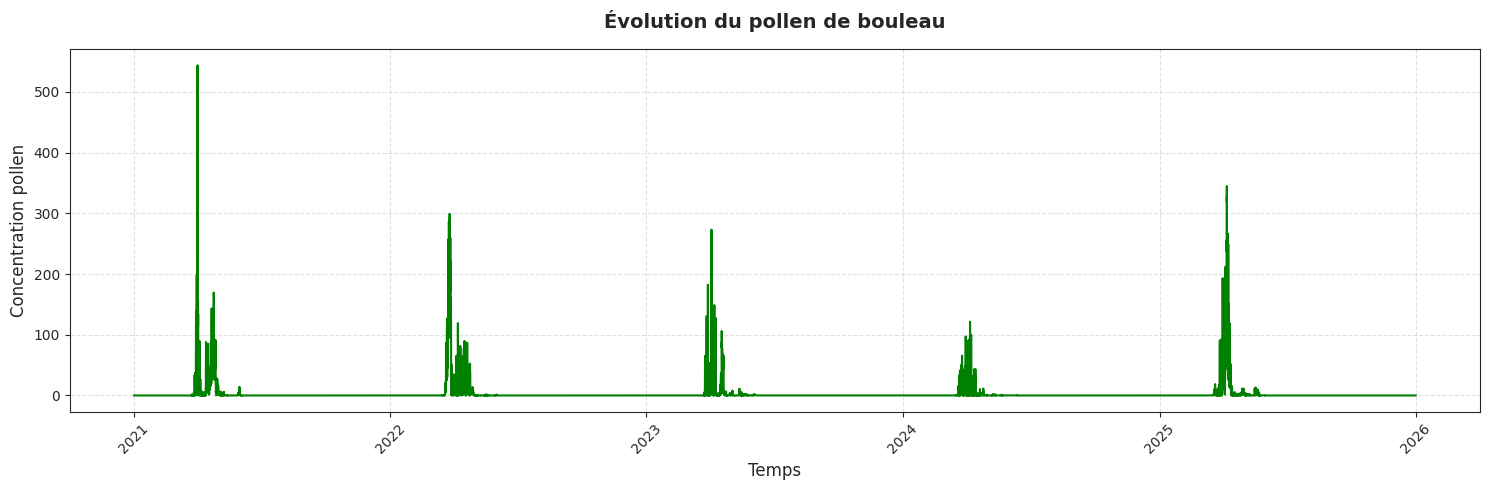

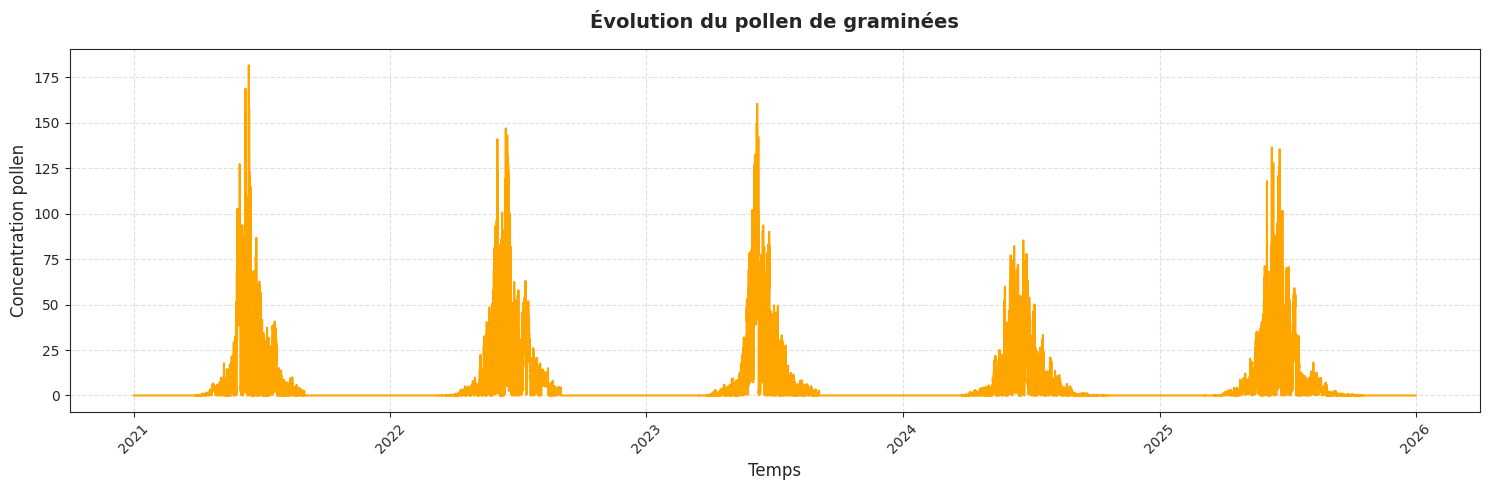

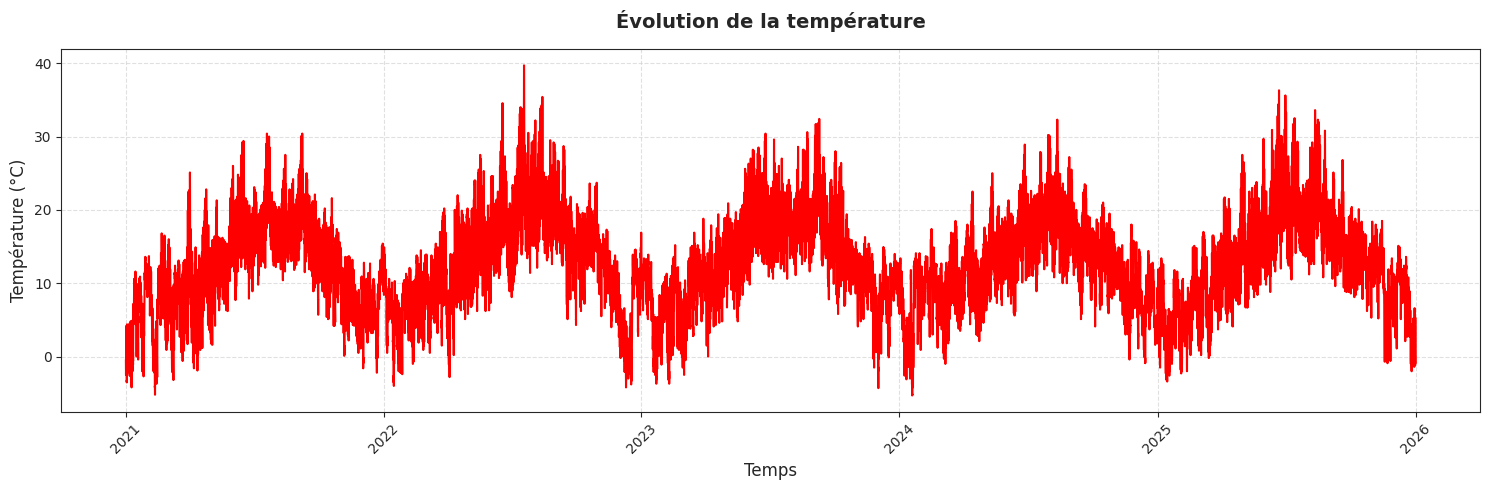

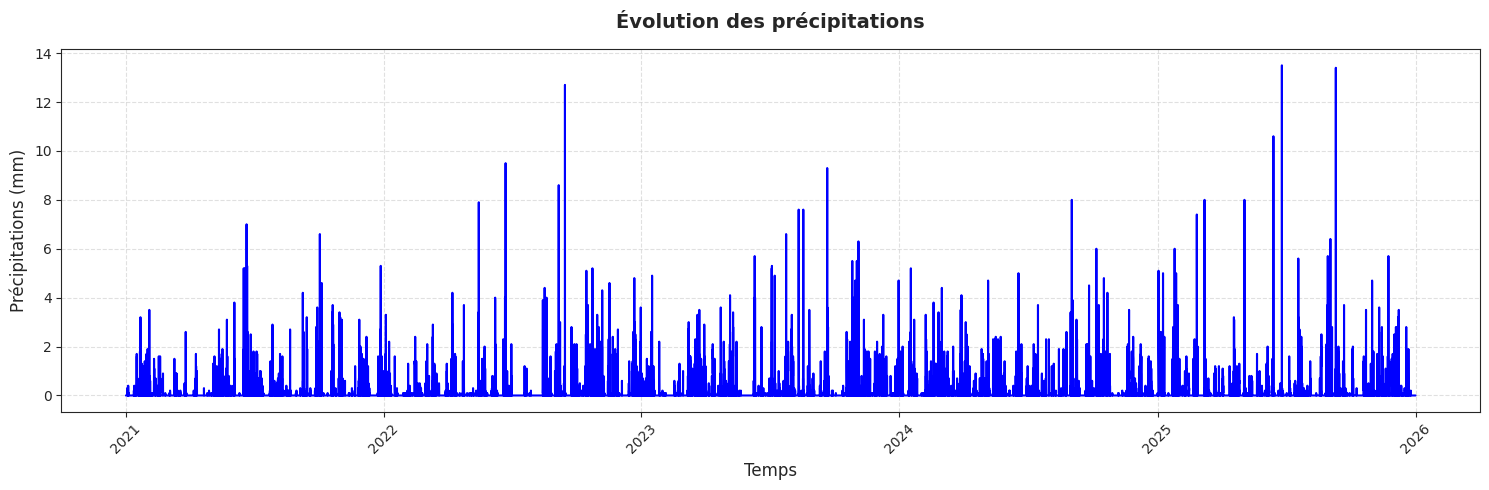

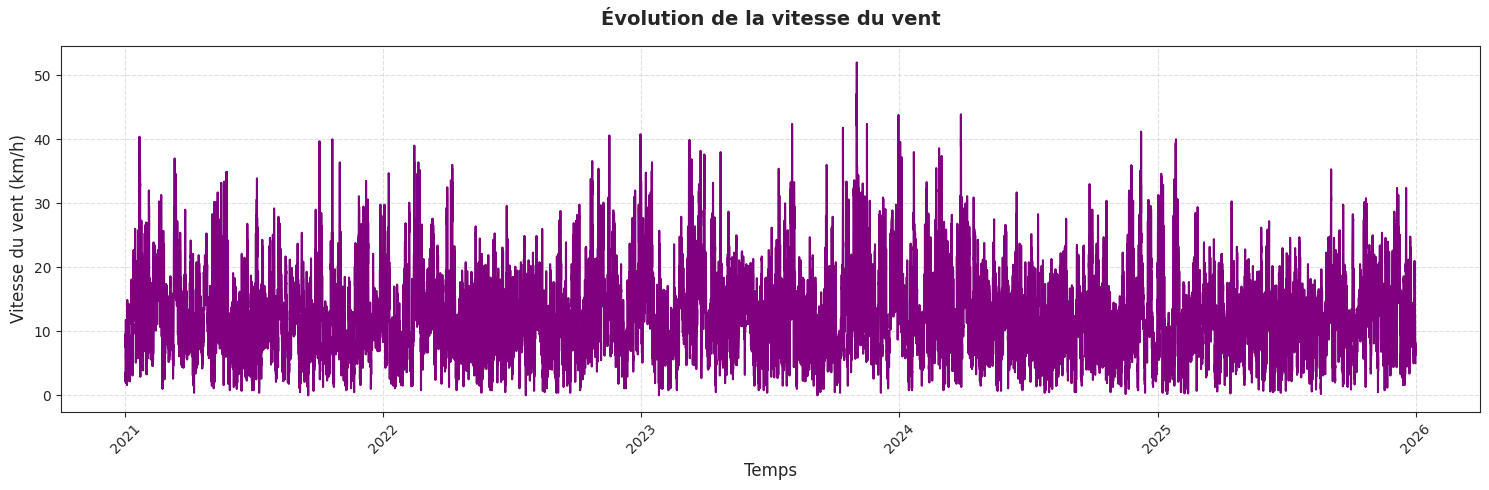

In [19]:
tracer_series_temporelles(
    df=df_pollen_meteo_clean,
    variables=[
        "pollen_bouleau",
        "pollen_graminees",
        "temperature",
        "precipitations",
        "vitesse_vent"
    ],
    titres={
        "pollen_bouleau": "Évolution du pollen de bouleau",
        "pollen_graminees": "Évolution du pollen de graminées",
        "temperature": "Évolution de la température",
        "precipitations": "Évolution des précipitations",
        "vitesse_vent": "Évolution de la vitesse du vent"
    },
    ylabels={
        "pollen_bouleau": "Concentration pollen",
        "pollen_graminees": "Concentration pollen",
        "temperature": "Température (°C)",
        "precipitations": "Précipitations (mm)",
        "vitesse_vent": "Vitesse du vent (km/h)"
    },
    couleurs={
        "pollen_bouleau": "green",
        "pollen_graminees": "orange",
        "temperature": "red",
        "precipitations": "blue",
        "vitesse_vent": "purple"
    }
)

####  Creation des données journalières 

In [20]:
# Agrégation journalière
df_jour = df_pollen_meteo_clean.resample('D', on='date').agg(
    pollen_bouleau=('pollen_bouleau', 'max'),
    pollen_graminees=('pollen_graminees', 'max'),
    temperature=('temperature', 'mean'),
    precipitations=('precipitations', 'sum'),
    vitesse_vent=('vitesse_vent', 'mean')
).reset_index()

sauvegarder_donnees_clean(
    df=df_jour,
    nom_fichier="df_pollen_meteo_jour.csv",
    dossier="data/clean"
)

print(df_jour.shape)
df_jour.head()



Données sauvegardées dans : data/clean/df_pollen_meteo_jour.csv
(1826, 6)


,date,pollen_bouleau,pollen_graminees,temperature,precipitations,vitesse_vent
0,2021-01-01,0.0,0.0,-0.233333,0.0,7.483333
1,2021-01-02,0.0,0.0,-0.258333,0.0,5.045833
2,2021-01-03,0.0,0.0,1.225000,1.7,7.883333
3,2021-01-04,0.0,0.0,1.129167,1.4,9.716667
4,2021-01-05,0.0,0.0,1.812500,0.1,10.504167


## 3.3. Feature engeneering

Pour des raisons justifiées ci dessous,  les variables à inclure dans notre modèle sont se présentent comme suit:

#### Température — le déclencheur principal

La floraison ne réagit pas à la température du jour même, mais à une accumulation de chaleur sur plusieurs jours. Les recherches en phénologie végétale montrent trois horizons pertinents :

| Feature        | Fenêtre          | Justification biologique |
|----------------|------------------|---------------------------|
| temp_lag1      | J-1              | Réaction immédiate de dispersion (un vent chaud peut entrainer la libération de pollen) |
| temp_roll7     | moy J-7→J-1      |une  "Semaine douce" peut être un signal de floraison imminent |
| temp_roll14    | moy J-14→J-1     | Une accumulation thermique lente peut déclencher les premières fleurs |



#### Précipitations — l'effet lavage

La pluie agit très vite (24–48h) en lavant les particules de l'air. Au-delà de 3 jours, l'effet deviendrait négligeable.

| Feature        | Fenêtre          | Justification |
|----------------|------------------|--------------|
| precip_lag1    | J-1              | Effet du lavage immédiatement le lendemain |
| precip_lag2    | J-2              | Effet résiduel du lavage 48h après |
| precip_roll7   | somme J-7→J-1    | une période sèche prolongée entrainerait une accumulation de pollen |

 Pour la pluie journalière, on prend une **somme (cumul)**, pas une moyenne — ce qui compte, c'est la quantité totale tombée.



#### Vent — le transporteur

Le vent influence la concentration locale mais son effet est immédiat, pas cumulatif.

| Feature        | Fenêtre          | Justification |
|----------------|------------------|--------------|
| wind_lag1      | J-1              | Une dispersion la veille affecte ce qu'on mesure aujourd'hui |
| wind_roll7     | moy J-7→J-1      | Un vent fort le long de la semaine pourrait réduire la concentration de pollen dans un site côtier comme Rennes |

In [21]:
# ════════════════════════════════════════════════════════
# 1. FEATURES TEMPORELLES
# ════════════════════════════════════════════════════════

df_jour["jour_de_annee"] = df_jour["date"].dt.dayofyear
df_jour["mois"]          = df_jour["date"].dt.month
df_jour["annee"]         = df_jour["date"].dt.year
df_jour["saison"]        = df_jour["mois"].map({
    12:0, 1:0, 2:0,
     3:1, 4:1, 5:1,
     6:2, 7:2, 8:2,
     9:3,10:3,11:3
})

# Encodage cyclique
df_jour["jour_sin"] = np.sin(2 * np.pi * df_jour["jour_de_annee"] / 365)
df_jour["jour_cos"] = np.cos(2 * np.pi * df_jour["jour_de_annee"] / 365)
df_jour["mois_sin"] = np.sin(2 * np.pi * df_jour["mois"] / 12)
df_jour["mois_cos"] = np.cos(2 * np.pi * df_jour["mois"] / 12)

# ════════════════════════════════════════════════════════
# 2. FEATURES MÉTÉO LAGGÉES ET GLISSANTES
# ════════════════════════════════════════════════════════

df_jour["temp_lag1"]   = df_jour["temperature"].shift(1)
df_jour["temp_roll7"]  = df_jour["temperature"].shift(1).rolling(7).mean()
df_jour["temp_roll14"] = df_jour["temperature"].shift(1).rolling(14).mean()

df_jour["precip_lag1"]  = df_jour["precipitations"].shift(1)
df_jour["precip_lag2"]  = df_jour["precipitations"].shift(2)
df_jour["precip_roll7"] = df_jour["precipitations"].shift(1).rolling(7).sum()

df_jour["vitesse_vent_lag1"]  = df_jour["vitesse_vent"].shift(1)
df_jour["vitesse_vent_roll7"] = df_jour["vitesse_vent"].shift(1).rolling(7).mean()

# ════════════════════════════════════════════════════════
# 3. DEGRÉS-JOURS CUMULÉS (GDD)
# ════════════════════════════════════════════════════════

df_jour["gdd_daily"] = (df_jour["temperature"] - 5).clip(lower=0)
df_jour["gdd_cumul"] = df_jour.groupby("annee")["gdd_daily"].cumsum()

# ════════════════════════════════════════════════════════
# 4. LAGS POLLEN (features)
# ════════════════════════════════════════════════════════

for col in ['pollen_bouleau', 'pollen_graminees']:
    for lag in [1, 2, 3]:
        df_jour[f'{col}_lag{lag}'] = df_jour[col].shift(lag)
    df_jour[f'{col}_moy3j'] = df_jour[col].shift(1).rolling(3).mean()

# ════════════════════════════════════════════════════════
# 5. VARIABLE CIBLE
# ════════════════════════════════════════════════════════

df_jour['risque_bouleau_j1'] = df_jour['pollen_bouleau'].apply(classifier_risque).shift(-1)
df_jour['risque_graminees_j1'] = df_jour['pollen_graminees'].apply(classifier_risque).shift(-1)

# ════════════════════════════════════════════════════════
# 6. NETTOYAGE
# ════════════════════════════════════════════════════════

df_jour_modele = df_jour.dropna().reset_index(drop=True)

print(f"Shape final : {df_jour_modele.shape}")
print(f"\nDistribution - Bouleau :")
print(df_jour_modele['risque_bouleau_j1'].value_counts())
print(f"\nDistribution - Graminées :")
print(df_jour_modele['risque_graminees_j1'].value_counts())



NameError: name 'classifier_risque' is not defined

In [ ]:
# Sauvegarde optionnelle pour réutilisation
sauvegarder_donnees_clean(
    df=df_jour_modele,
    nom_fichier="df_jour_modele.csv",
    dossier="data/clean"
)

NameError: name 'df_jour_modele' is not defined

## 3.4 Définition des variables pour la modélisation

In [ ]:
features = [
    # Temporelles
    'jour_sin', 'jour_cos', 'mois_sin', 'mois_cos', 'saison', 'annee',
    # Température
    'temp_lag1', 'temp_roll7', 'temp_roll14', 'gdd_cumul',
    # Précipitations
    'precip_lag1', 'precip_lag2', 'precip_roll7',
    # Vent
    'vitesse_vent_lag1', 'vitesse_vent_roll7',
    # Lags pollen
    'pollen_bouleau_lag1', 'pollen_bouleau_lag2', 'pollen_bouleau_lag3',
    'pollen_bouleau_moy3j',
    'pollen_graminees_lag1', 'pollen_graminees_lag2', 'pollen_graminees_lag3',
    'pollen_graminees_moy3j'
]

features_meteo = [
    'jour_sin', 'jour_cos', 'mois_sin', 'mois_cos', 'saison', 'annee',
    'temp_lag1', 'temp_roll7', 'temp_roll14', 'gdd_cumul',
    'precip_lag1', 'precip_lag2', 'precip_roll7',
    'vitesse_vent_lag1', 'vitesse_vent_roll7'
]

print("Features complètes :", len(features))
print("Features météo :", len(features_meteo))

# 4. Modélisation

## 4.1 Préparation des données

### 4.1.1 Déséquilibre des classes

La distribution des classes révèle un fort déséquilibre, avec une très forte prédominance de la classe 0 (absence de pic ou de risque faible) pour les deux taxons. Afin de comprendre l’origine de ce déséquilibre et son impact potentiel sur le modèle, nous avons exploré deux contextes temporels distincts :

- un apprentissage sur toute l’année, incluant notamment les périodes hivernales où la concentration pollinique est naturellement très faible ou nulle ;
- un apprentissage restreint à la saison pollinique, c’est‑à‑dire les périodes où l’on attend a priori des épisodes à risque (par exemple, mars à juillet pour le bouleau et mai à septembre pour les graminées).

Les proportions observées sont les suivantes :

|Type| Toute l'année | Saison pollinique |
|--|--|--|
| Bouleau classe 0 | 94% | 87% |
| Graminées classe 0 | 85% | 66% |


Le filtrage sur la saison pollinique améliore légèrement l’équilibre pour les graminées, mais reste insuffisant pour le bouleau, où la classe 0 demeure très majoritaire. Étant donné que notre objectif est de développer un modèle exploitable sur l’ensemble de l’année, nous avons donc choisi de conserver toutes les données, afin de préserver la dynamique réelle de la présence pollinique au cours du cycle saisonnier.

Le déséquilibre est donc traité au niveau de l’apprentissage en utilisant `class_weight='balanced'`, ce qui permet de diminuer l’influence de la classe majoritaire. Par ailleurs, nous privilégions des métriques adaptées comme le **F1‑score macro** plutôt que l’accuracy seule, afin de mieux apprécier la performance sur les classes minoritaires correspondant aux pics de risque.

In [ ]:
print("Distribution - Bouleau :")
print(df_jour_modele['risque_bouleau_j1'].value_counts())
print("\nDistribution - Graminées :")
print(df_jour_modele['risque_graminees_j1'].value_counts())

### 4.1.3 Split temporel train/test

Contrairement à un split aléatoire classique, nous respectons l’ordre chronologique des données, conformément aux bonnes pratiques pour les séries temporelles. Le modèle est entraîné sur la période 2021–2024 et évalué sur la période 2025–2026 (avril), de manière à simuler une utilisation prospective dans un contexte opérationnel de prévision pollinique.

In [ ]:
train = df_jour_modele[df_jour_modele['date'].dt.year <= 2024]
test = df_jour_modele[df_jour_modele['date'].dt.year >= 2025]

X_train = train[features]
X_test = test[features]

y_train_bouleau = train['risque_bouleau_j1'].astype(int)
y_test_bouleau = test['risque_bouleau_j1'].astype(int)

y_train_graminees = train['risque_graminees_j1'].astype(int)
y_test_graminees = test['risque_graminees_j1'].astype(int)

print("Train :", X_train.shape)
print("Test :", X_test.shape)
print("\nAnnées train :", sorted(train['date'].dt.year.unique()))
print("Années test :", sorted(test['date'].dt.year.unique()))

## 4.2 Modélisation

### 4.2.1 Pipeline preprocessing + modèles

Nous construisons un pipeline scikit‑learn qui intègre à la fois les étapes de preprocessing et les modèles, afin de garantir une application cohérente aux données d'entraînement et de test. 
Ce pipeline comprend :

- **StandardScaler** : standardisation des variables continues, nécessaire pour la régression logistique et souvent bénéfique pour d'autres modèles à base de distance.
- **Quatre modèles** : une régression logistique (baseline), un arbre de décision, un Random Forest et un XGBoost, permettant de comparer des méthodes simples, ensemblistes et boostées.
- **GridSearchCV** avec `TimeSeriesSplit` : sélectionne les meilleurs  hyperparamètres tout en respectant l'ordre chronologique des données.
- **F1‑macro** comme métrique d'évaluation : adapté au déséquilibre des classes, il permet de mieux apprécier la performance sur les classes minoritaires qu'un simple score de précision.

#### Pipeline avec preprocessing et modèle


In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modele', LogisticRegression())
])


#### Grille de paramètres pour les 3 modèles
